<img src="hcv.png" />

<div dir="rtl" align="right">
<b>استيراد المكتبات</b><br>
نستورد مكتبة <code>cv2</code> لمعالجة الصور، و<code>matplotlib</code> لعرضها، و<code>numpy</code> للعمليات على المصفوفات.
</div>

In [57]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

<div dir="rtl" align="right">
<b>قراءة صورة لافتة التوقف</b><br>
نستخدم <code>cv2.imread()</code> لتحميل صورة لافتة التوقف (Stop Sign) من القرص وتخزينها في المتغير <code>image</code> بنظام BGR.
</div>

In [58]:
image = cv2.imread('stop_sign.jpg')

<div dir="rtl" align="right">
<b>عرض الصورة الأصلية</b><br>
نحوّل الصورة من BGR إلى RGB ثم نعرضها باستخدام Matplotlib حتى تظهر الألوان بشكل صحيح.
</div>

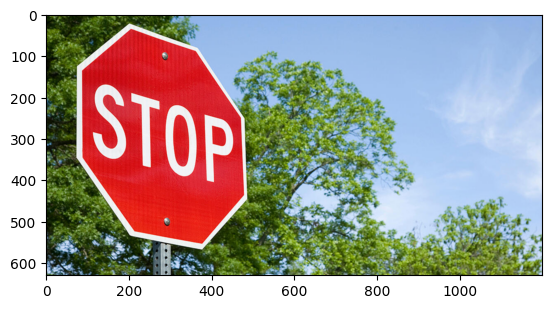

In [59]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

<div dir="rtl" align="right">
<b>تقسيم الصورة إلى قنوات B و G و R</b><br>
نستخدم <code>cv2.split()</code> لفصل الصورة إلى ثلاث قنوات لونية مستقلة: الأزرق (B) والأخضر (G) والأحمر (R)، كل منها مصفوفة ثنائية الأبعاد.
</div>

In [60]:
B, G , R = cv2.split(image)

<div dir="rtl" align="right">
<b>عرض قيم قناة الأخضر (G)</b><br>
نعرض مصفوفة قناة الأخضر لرؤية قيم البكسلات الخاصة بها، حيث تتراوح القيم بين 0 و255.
</div>

In [61]:
G

array([[138, 144, 133, ..., 176, 176, 176],
       [123, 127, 119, ..., 176, 176, 176],
       [ 99, 104, 101, ..., 176, 176, 176],
       ...,
       [ 83,  99, 129, ..., 221, 216, 207],
       [ 82,  85, 103, ..., 225, 213, 193],
       [ 99,  79,  77, ..., 227, 210, 182]],
      shape=(630, 1200), dtype=uint8)

<div dir="rtl" align="right">
<b>عرض مصفوفة الصورة الأصلية</b><br>
نعرض محتوى مصفوفة الصورة الكاملة كمصفوفة ثلاثية الأبعاد (ارتفاع × عرض × 3 قنوات) بترتيب BGR.
</div>

In [62]:
image

array([[[ 70, 138, 113],
        [ 76, 144, 119],
        [ 65, 133, 108],
        ...,
        [229, 176, 143],
        [229, 176, 143],
        [229, 176, 143]],

       [[ 52, 123,  97],
        [ 56, 127, 101],
        [ 46, 119,  93],
        ...,
        [229, 176, 143],
        [229, 176, 143],
        [229, 176, 143]],

       [[ 25,  99,  73],
        [ 30, 104,  78],
        [ 27, 101,  75],
        ...,
        [229, 176, 143],
        [229, 176, 143],
        [229, 176, 143]],

       ...,

       [[ 61,  83,  59],
        [ 61,  99,  71],
        [ 79, 129,  97],
        ...,
        [253, 221, 202],
        [242, 216, 192],
        [230, 207, 181]],

       [[ 91,  82,  62],
        [ 71,  85,  61],
        [ 61, 103,  72],
        ...,
        [255, 225, 204],
        [236, 213, 187],
        [214, 193, 165]],

       [[122,  99,  73],
        [ 80,  79,  51],
        [ 47,  77,  48],
        ...,
        [253, 227, 203],
        [231, 210, 182],
        [197, 182, 150]]

<div dir="rtl" align="right">
<b>التحقق من أبعاد قناة B</b><br>
نطبع شكل قناة الأزرق للتحقق من أبعادها. الناتج <code>(630, 1200)</code> يعني أن القناة مصفوفة ثنائية الأبعاد فقط بدون قناة لونية.
</div>

In [63]:
B.shape

(630, 1200)

<div dir="rtl" align="right">
<b>عرض قناة الأزرق (B) بتدرج رمادي</b><br>
نعرض قناة الأزرق كصورة رمادية باستخدام <code>cmap="gray"</code>، حيث تمثل شدة كل بكسل مقدار اللون الأزرق فيه.
</div>

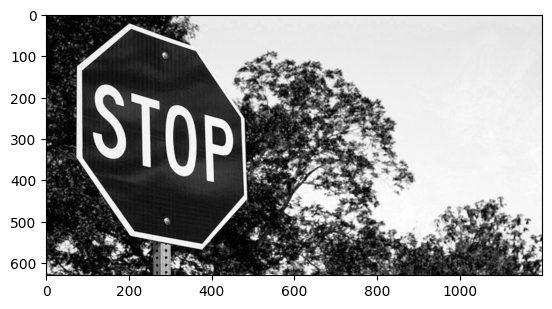

In [64]:
plt.imshow(B, cmap='gray', vmin = 0, vmax = 255)
plt.show()

<div dir="rtl" align="right">
<b>عرض قناة الأخضر (G) بتدرج رمادي</b><br>
نعرض قناة الأخضر كصورة رمادية. البكسلات الأكثر إضاءة تعني وجود كمية أكبر من اللون الأخضر.
</div>

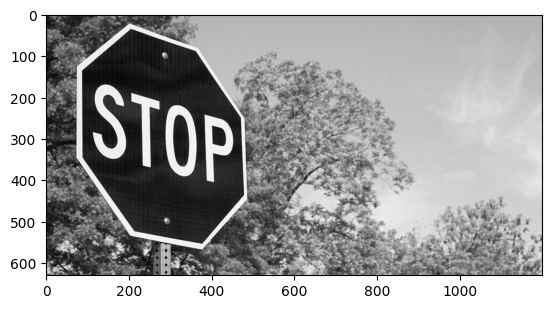

In [65]:
plt.imshow(G, cmap='gray', vmin = 0, vmax = 255)
plt.show()

<div dir="rtl" align="right">
<b>عرض قناة الأحمر (R) بتدرج رمادي</b><br>
نعرض قناة الأحمر كصورة رمادية. لاحظ أن لافتة التوقف ستظهر ذات إضاءة عالية لأنها حمراء اللون.
</div>

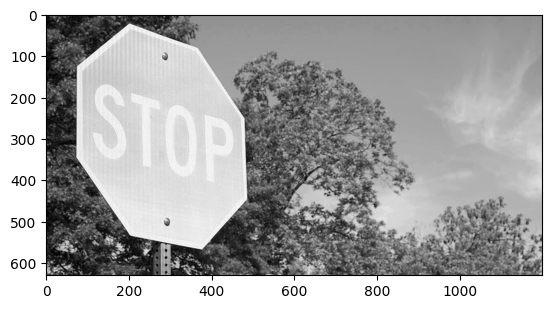

In [66]:
plt.imshow(R, cmap='gray', vmin = 0, vmax = 255)
plt.show()

<img src="hsv.png">

<div dir="rtl" align="right">
<b>تحويل الصورة إلى نظام HSV ونسخها</b><br>
نحوّل الصورة من BGR إلى نظام HSV (Hue, Saturation, Value) الذي يفصل معلومة اللون عن الإضاءة، مما يجعل اكتشاف الألوان أسهل وأكثر دقة.
</div>

In [67]:
image2 = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
result = image2.copy()

<img src="hsvmask.png" />

<div dir="rtl" align="right">
<b>عرض مصفوفة الصورة بنظام HSV</b><br>
نعرض محتوى الصورة بعد التحويل إلى HSV. القيم الثلاثة لكل بكسل تمثل الآن (Hue: اللون، Saturation: التشبع، Value: السطوع).
</div>

In [21]:
result

array([[[ 41, 126, 138],
        [ 41, 120, 144],
        [ 41, 130, 133],
        ...,
        [109,  96, 229],
        [109,  96, 229],
        [109,  96, 229]],

       [[ 41, 147, 123],
        [ 41, 143, 127],
        [ 41, 156, 119],
        ...,
        [109,  96, 229],
        [109,  96, 229],
        [109,  96, 229]],

       [[ 41, 191,  99],
        [ 41, 181, 104],
        [ 41, 187, 101],
        ...,
        [109,  96, 229],
        [109,  96, 229],
        [109,  96, 229]],

       ...,

       [[ 63,  74,  83],
        [ 52,  98,  99],
        [ 49,  99, 129],
        ...,
        [109,  51, 253],
        [106,  53, 242],
        [104,  54, 230]],

       [[ 99,  81,  91],
        [ 73,  72,  85],
        [ 52, 104, 103],
        ...,
        [108,  51, 255],
        [104,  53, 236],
        [103,  58, 214]],

       [[104, 102, 122],
        [ 91,  92,  80],
        [ 59,  99,  77],
        ...,
        [106,  50, 253],
        [103,  54, 231],
        [100,  61, 197]]

<div dir="rtl" align="right">
<b>تحديد نطاق اللون الأحمر في HSV</b><br>
نحدد حدود اللون الأحمر في فضاء HSV. اللون الأحمر يظهر في طرفي دائرة الألوان لذلك نحتاج نطاقين: الأول من 0 إلى 10، والثاني من 160 إلى 180.
</div>

In [69]:
lower1 = np.array([0,50,50])
upper1 = np.array([10,255,255])

lower2 = np.array([160,50,50])
upper2 = np.array([180,255,255])

<div dir="rtl" align="right">
<b>إنشاء قناع اللون الأحمر (Mask)</b><br>
نستخدم <code>cv2.inRange()</code> لإنشاء قناعين ثنائيين: الأبيض (255) للبكسلات ضمن النطاق والأسود (0) لما خارجه. ثم نجمع القناعين للحصول على قناع اللون الأحمر الكامل.
</div>

In [70]:
mask1 = cv2.inRange(result,lower1,upper1)
mask2 = cv2.inRange(result,lower2,upper2)

mask = mask1+mask2

In [71]:
mask1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(630, 1200), dtype=uint8)

<div dir="rtl" align="right">
<b>عرض القناع الأول (mask1)</b><br>
نعرض القناع الأول الذي يعزل اللون الأحمر في النطاق 0-10 من Hue. المناطق البيضاء هي المناطق التي تحتوي على اللون الأحمر ضمن هذا النطاق.
</div>

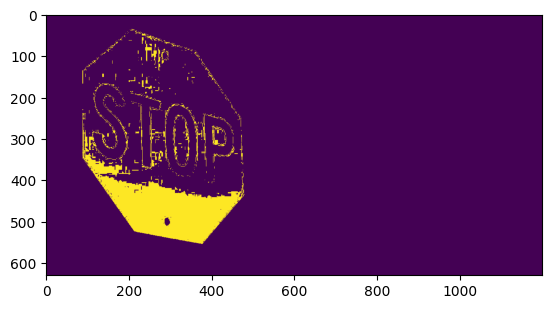

In [72]:
plt.imshow(mask1)

<div dir="rtl" align="right">
<b>عرض القناع الثاني (mask2)</b><br>
نعرض القناع الثاني الذي يعزل اللون الأحمر في النطاق 160-180 من Hue. يُكمل هذا القناع الأول لتغطية كامل اللون الأحمر.
</div>

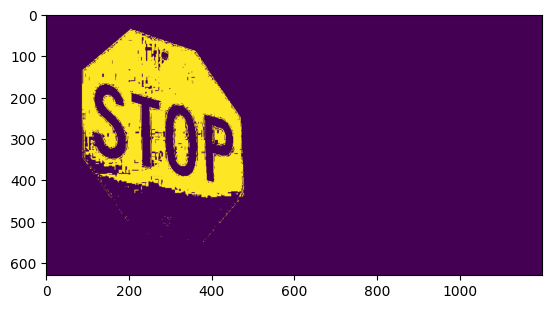

In [73]:
plt.imshow(mask2)

<div dir="rtl" align="right">
<b>عرض القناع المدمج (mask)</b><br>
نعرض القناع النهائي الناتج عن دمج القناعين، والذي يُبرز جميع مناطق اللون الأحمر في الصورة.
</div>

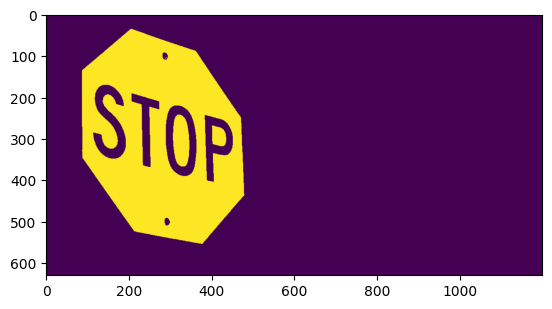

In [74]:
plt.imshow(mask)

<div dir="rtl" align="right">
<b>تطبيق القناع على الصورة باستخدام AND</b><br>
نستخدم <code>cv2.bitwise_and()</code> لتطبيق القناع على صورة HSV، فتبقى فقط البكسلات ذات اللون الأحمر ويتحول الباقي إلى أسود.
</div>

In [75]:
result = cv2.bitwise_and(result,result,mask=mask)

<div dir="rtl" align="right">
<b>عرض النتيجة النهائية بعد تطبيق القناع</b><br>
نحوّل النتيجة من HSV إلى RGB ونعرضها. ستظهر فقط الأجزاء الحمراء من الصورة (لافتة التوقف) بينما يكون باقي الصورة أسود.
</div>

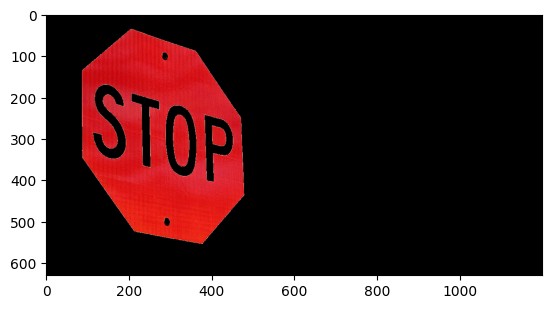

In [77]:
plt.imshow(cv2.cvtColor(result, cv2.COLOR_HSV2RGB))
plt.show()

In [78]:
iimg=cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
iimg

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(630, 1200, 3), dtype=uint8)

<div dir="rtl" align="right">
<b>عرض الصورة الأصلية للمقارنة</b><br>
نعرض الصورة الأصلية مرة أخرى للمقارنة مع النتيجة بعد تطبيق القناع، لنرى مدى دقة عزل اللون الأحمر.
</div>

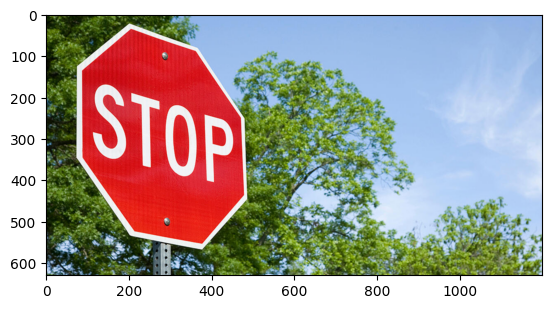

In [79]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()